In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
orders = pd.read_csv(r'C:\Users\Raghav Ratan Yadav\Downloads\Pizza+Place+Sales\pizza_sales\orders.csv')
order_details = pd.read_csv(r'C:\Users\Raghav Ratan Yadav\Downloads\Pizza+Place+Sales\pizza_sales\order_details.csv')
pizzas = pd.read_csv(r'C:\Users\Raghav Ratan Yadav\Downloads\Pizza+Place+Sales\pizza_sales\pizzas.csv')
pizza_types = pd.read_csv(r'C:\Users\Raghav Ratan Yadav\Downloads\Pizza+Place+Sales\pizza_sales\pizzatypes.csv', encoding='ISO-8859-1')


,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


In [20]:
orders.head()
orders.shape
orders.isnull().sum()

order_id    0
date        0
time        0
dtype: int64

In [22]:
order_details.head()
order_details.shape
order_details.isnull().sum()

order_details_id    0
order_id            0
pizza_id            0
quantity            0
dtype: int64

In [24]:
pizzas.head()
pizzas.shape
pizzas.isnull().sum()

pizza_id         0
pizza_type_id    0
size             0
price            0
dtype: int64

In [26]:
pizza_types.head()
pizza_types.shape
pizza_types.isnull().sum()

pizza_type_id    0
name             0
category         0
ingredients      0
dtype: int64

In [32]:
df = order_details.merge(orders, on = 'order_id')
df = df.merge(pizzas, on = 'pizza_id')
df = df.merge(pizza_types, on = 'pizza_type_id')
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [72]:
#Total revenue of the year

df['revenue'] = df['quantity']*df['price']
total_revenue = df['revenue'].sum()
print("Total revenue of the year is:", round(total_revenue,2))

Total revenue of the year is: 817860.05


In [73]:
#Total orders of the year

print("Total orders of the year:", df.order_id.nunique())

Total orders of the year: 21350


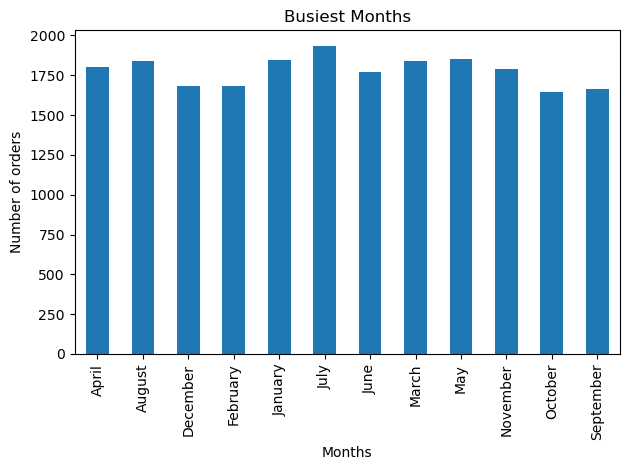

In [106]:
#Which months are busiest?

df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month_name()
df.groupby('month')['order_id'].nunique().plot(kind = 'bar')
plt.title('Busiest Months')
plt.xlabel('Months')
plt.ylabel('Number of orders')
plt.tight_layout()
plt.show()

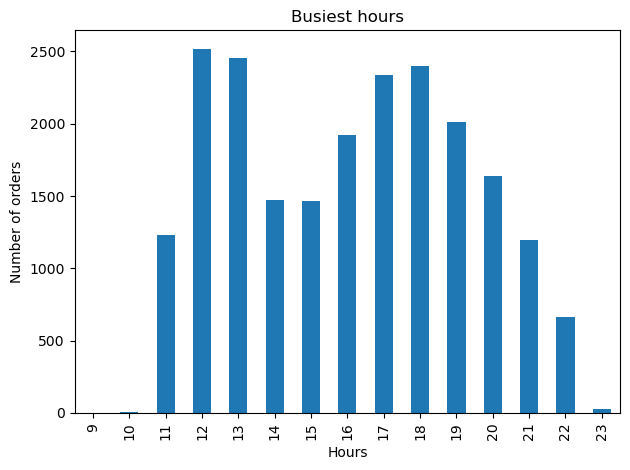

In [107]:
#Which hours are busiest?

df['time'] = pd.to_datetime(df['time'])
df['hours'] = df['time'].dt.hour
df.groupby('hours')['order_id'].nunique().plot(kind = 'bar')
plt.title('Busiest hours')
plt.xlabel('Hours')
plt.ylabel('Number of orders')
plt.tight_layout()
plt.show()

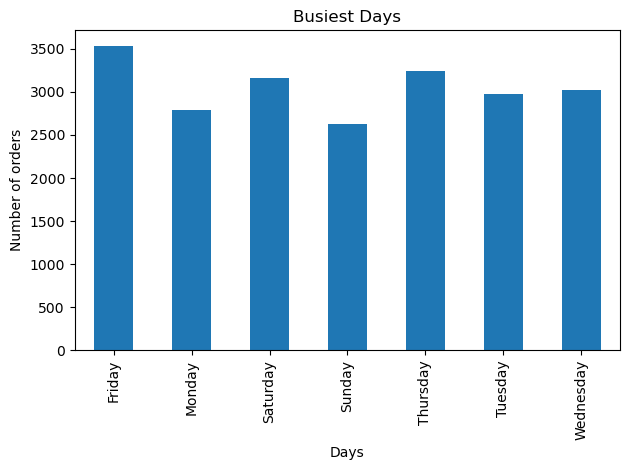

In [108]:
#Which days are busiest?

df['days'] = df['date'].dt.day_name()
df.groupby('days')['order_id'].nunique().plot(kind = 'bar')
plt.title('Busiest Days')
plt.xlabel('Days')
plt.ylabel('Number of orders')
plt.tight_layout()
plt.show()

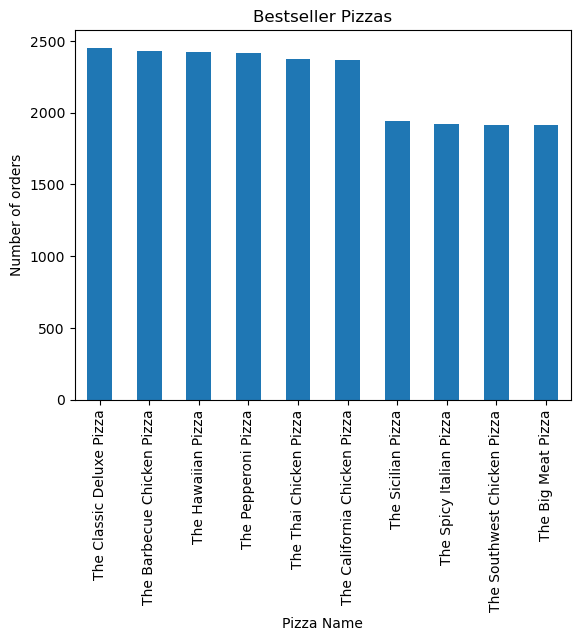

In [119]:
#Which pizzas are our bestsellers?

df.groupby('name')['quantity'].sum().sort_values(ascending = False).head(10).plot(kind = 'bar')
plt.title('Bestseller Pizzas')
plt.xlabel('Pizza Name')
plt.ylabel('Number of orders')
plt.show()

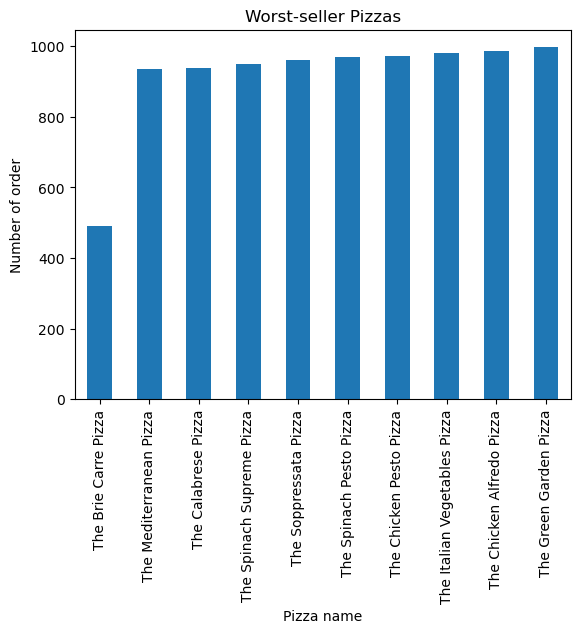

In [114]:
#Which pizzas are our worst sellers?

df.groupby('name')['quantity'].sum().sort_values().head(10).plot(kind = 'bar')
plt.title('Worst-seller Pizzas')
plt.xlabel('Pizza name')
plt.ylabel('Number of order')
plt.show()

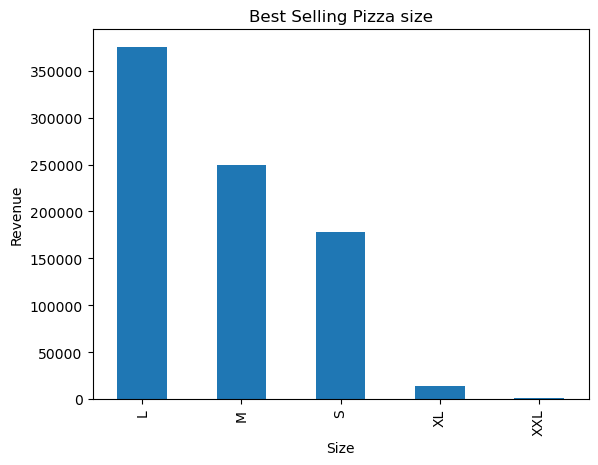

In [113]:
#Which pizza size makes the most revenue

df.groupby('size')['revenue'].sum().sort_values(ascending = False).plot(kind = 'bar')
plt.title('Best Selling Pizza size')
plt.xlabel('Size')
plt.ylabel('Revenue')
plt.show()

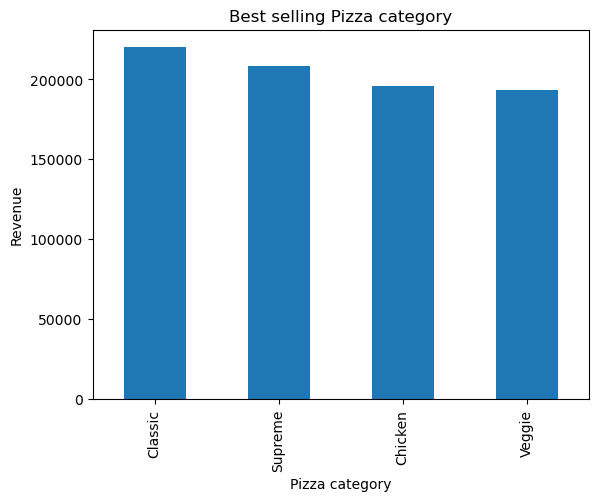

In [115]:
#Which pizza category makes the most revenue


df.groupby('category')['revenue'].sum().sort_values(ascending = False).plot(kind = 'bar')
plt.title('Best selling Pizza category')
plt.xlabel('Pizza category')
plt.ylabel('Revenue')
plt.show()

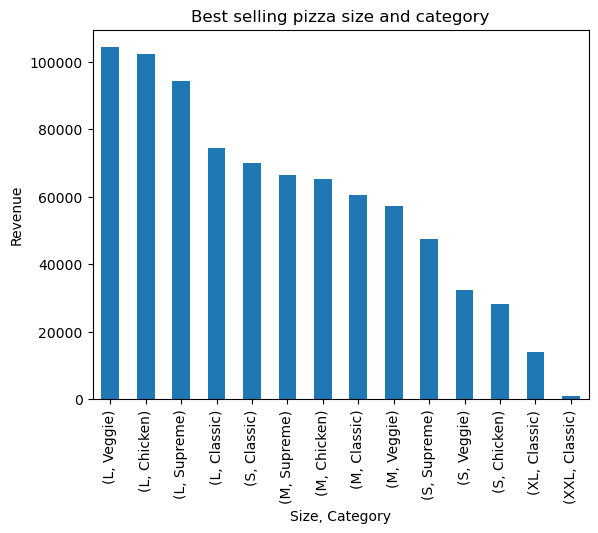

In [116]:
#Which pizza size and category makes the most revenue

df.groupby(['size', 'category'])['revenue'].sum().sort_values(ascending = False).plot(kind = 'bar')
plt.title('Best selling pizza size and category')
plt.xlabel('Size, Category')
plt.ylabel('Revenue')
plt.show()

1. PROMOTE → Classic Deluxe Pizza — highest quantity sold. Run targeted discounts or combos to increase order value.

2. DISCONTINUE → The Brie Carre Pizza — only ~500 orders 
   in the full year. Low demand, not worth menu space.

3. STAFF MORE ON → Friday between 12 P.M.
   — highest order volume consistently during this window.

4. FOCUS ON → Large size in Classic category — 
   generates highest revenue per order.